In [1]:
!pip install folium

               FIPS          Lat        Long_     Confirmed         Deaths  \
count   3268.000000  3925.000000  3925.000000  4.016000e+03    4016.000000   
mean   32405.943390    35.736183   -71.109728  1.646409e+05    1667.277141   
std    18056.381177    13.441327    55.361480  1.046512e+06    8705.465768   
min       60.000000   -71.949900  -178.116500  0.000000e+00       0.000000   
25%    19048.500000    33.191535   -96.595639  3.737500e+03      46.000000   
50%    30068.000000    37.895700   -86.717326  1.050600e+04     130.500000   
75%    47041.500000    42.176955   -77.357900  4.577550e+04     465.250000   
max    99999.000000    71.706900   178.065000  3.830609e+07  183348.000000   

       Recovered  Active  Incident_Rate  Case_Fatality_Ratio  
count        0.0     0.0    3922.000000          3974.000000  
mean         NaN     NaN   27693.653663             3.396156  
std          NaN     NaN   10388.048975            93.482133  
min          NaN     NaN       0.000000      

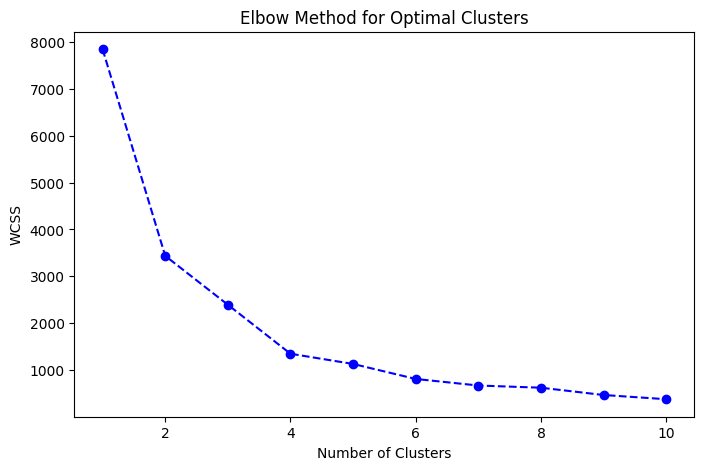

In [2]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Fetch Latest COVID-19 Data from GitHub ----
#base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/"
#latest_date = "02-13-2020.csv"  # Update with the latest date in MM-DD-YYYY format
#url = base_url + latest_date
#print(url)

# Load dataset
df = pd.read_csv('01-02-2023.csv')
print(df.describe())
df.head(1)
# ---- Data Preprocessing ----
# Select relevant columns
print(df.columns)  # Verify column names
columns_to_use = ["Country_Region", "Province_State", "Lat", "Long_", "Confirmed", "Deaths", "Recovered", "Active"]
df = df[columns_to_use]

# Handle missing values
df.fillna({'Confirmed': 0, 'Deaths': 0, 'Recovered': 0, 'Active': 0}, inplace=True)
df.dropna(subset=['Lat', 'Long_'], inplace=True)

# Normalize data for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Confirmed", "Deaths", "Recovered", "Active"]])

# ---- Apply K-Means Clustering ----
optimal_clusters = 5  # Change based on analysis
kmeans = KMeans(n_clusters=optimal_clusters, init="k-means++", max_iter=300, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# ---- Visualizing Clusters on a World Map ----
world_map = folium.Map(location=[20, 0], zoom_start=2)

marker_cluster = MarkerCluster().add_to(world_map)

for _, row in df.iterrows():
    folium.Marker(
        location=[row["Lat"], row["Long_"]],
        popup=f"Country: {row['Country_Region']}<br>Confirmed: {row['Confirmed']}<br>Deaths: {row['Deaths']}<br>Recovered: {row['Recovered']}",
        icon=folium.Icon(color=["red", "blue", "green", "purple", "orange"][row["Cluster"]])
    ).add_to(marker_cluster)

# Save map to an HTML file
world_map.save("covid19_clusters_map.html")
print("✅ World Map with Clusters Saved as 'covid19_clusters_map.html'")
#print("✅ Map saved successfully!")

# Open the saved file in Jupyter Notebook
import webbrowser
webbrowser.open("covid19_clusters_map.html")


# ---- Clustering Insights ----
print("\n📌 **Cluster Analysis Summary:**")
print(df.groupby("Cluster")[["Confirmed", "Deaths", "Recovered", "Active"]].mean())

# ---- Elbow Method to Find Optimal Clusters ----
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", max_iter=300, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [3]:
# Cell 1: Data Handling & Preprocessing

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('01-02-2023.csv')

# Select relevant columns
print("Dataset columns:", df.columns)
columns_to_use = ["Country_Region", "Province_State", "Lat", "Long_", "Confirmed", "Deaths", "Recovered", "Active"]
df = df[columns_to_use]

# Handle missing values
df.fillna({'Confirmed': 0, 'Deaths': 0, 'Recovered': 0, 'Active': 0}, inplace=True)
df.dropna(subset=['Lat', 'Long_'], inplace=True)

print(f"\nDataset shape after preprocessing: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head()

Dataset columns: Index(['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update',
       'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio'],
      dtype='object')

Dataset shape after preprocessing: (3925, 8)
Missing values:
Country_Region      0
Province_State    177
Lat                 0
Long_               0
Confirmed           0
Deaths              0
Recovered           0
Active              0
dtype: int64


,Country_Region,Province_State,Lat,Long_,Confirmed,Deaths,Recovered,Active
0,Afghanistan,NaN,33.93911,67.709953,207627,7849,0.0,0.0
1,Albania,NaN,41.15330,20.168300,333812,3595,0.0,0.0
2,Algeria,NaN,28.03390,1.659600,271229,6881,0.0,0.0
3,Andorra,NaN,42.50630,1.521800,47751,165,0.0,0.0
4,Angola,NaN,-11.20270,17.873900,105095,1930,0.0,0.0


Dataset Statistics:
               Lat        Long_     Confirmed         Deaths  Recovered  \
count  3925.000000  3925.000000  3.925000e+03    3925.000000     3925.0   
mean     35.736183   -71.109728  1.677179e+05    1691.606624        0.0   
std      13.441327    55.361480  1.058068e+06    8787.535668        0.0   
min     -71.949900  -178.116500  0.000000e+00       0.000000        0.0   
25%      33.191535   -96.595639  3.956000e+03      49.000000        0.0   
50%      37.895700   -86.717326  1.087200e+04     134.000000        0.0   
75%      42.176955   -77.357900  4.708500e+04     476.000000        0.0   
max      71.706900   178.065000  3.830609e+07  183348.000000        0.0   

       Active  
count  3925.0  
mean      0.0  
std       0.0  
min       0.0  
25%       0.0  
50%       0.0  
75%       0.0  
max       0.0  


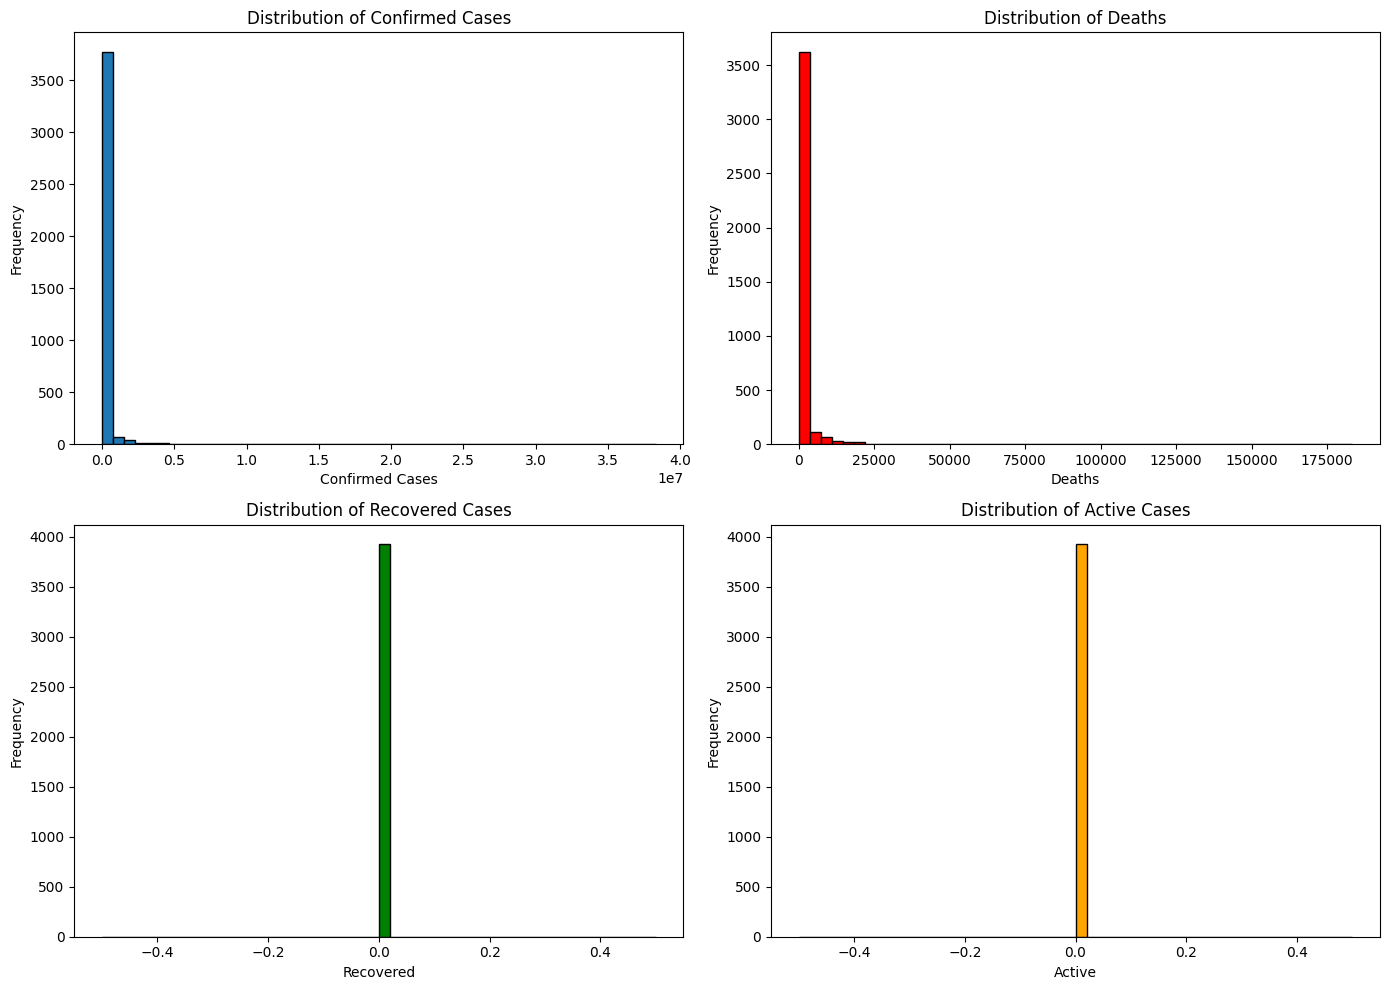

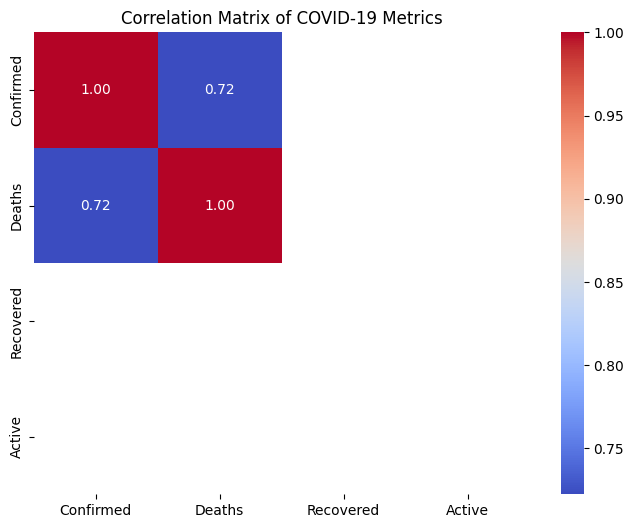

In [4]:
# Cell 2: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistics
print("Dataset Statistics:")
print(df.describe())

# Visualize distributions of key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Confirmed'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Confirmed Cases')
axes[0, 0].set_xlabel('Confirmed Cases')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['Deaths'], bins=50, edgecolor='black', color='red')
axes[0, 1].set_title('Distribution of Deaths')
axes[0, 1].set_xlabel('Deaths')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df['Recovered'], bins=50, edgecolor='black', color='green')
axes[1, 0].set_title('Distribution of Recovered Cases')
axes[1, 0].set_xlabel('Recovered')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(df['Active'], bins=50, edgecolor='black', color='orange')
axes[1, 1].set_title('Distribution of Active Cases')
axes[1, 1].set_xlabel('Active')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of COVID-19 Metrics')
plt.show()

In [5]:
# Cell 3: K-Means Clustering & Model Implementation

from sklearn.cluster import KMeans

# Normalize data for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Confirmed", "Deaths", "Recovered", "Active"]])

# Apply K-Means Clustering
optimal_clusters = 5  # Change based on elbow method or silhouette analysis
kmeans = KMeans(n_clusters=optimal_clusters, init="k-means++", max_iter=300, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"Cluster assignment completed with {optimal_clusters} clusters")
print(f"\nCluster distribution:\n{df['Cluster'].value_counts().sort_index()}")

# Display cluster centers
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=['Confirmed', 'Deaths', 'Recovered', 'Active'])
print("\nCluster Centers:")
print(cluster_centers_df)

Cluster assignment completed with 5 clusters

Cluster distribution:
Cluster
0    3831
1       8
2       2
3      82
4       2
Name: count, dtype: int64

Cluster Centers:
      Confirmed         Deaths  Recovered  Active
0  7.083671e+04     762.828504        0.0     0.0
1  6.401312e+06  134833.375000        0.0     0.0
2  3.376334e+07   95469.000000        0.0     0.0
3  2.813963e+06   26374.573171        0.0     0.0
4  1.871753e+07  142420.000000        0.0     0.0


In [ ]:
# Cell 4: Geospatial Clustering & Visualization

import folium
from folium.plugins import MarkerCluster
from IPython.display import IFrame

# Create base map
world_map = folium.Map(location=[20, 0], zoom_start=2)

# Define colors for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']

# Add markers for each cluster
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long_']],
        radius=5,
        popup=f"Country: {row['Country_Region']}<br>Cluster: {row['Cluster']}<br>Confirmed: {row['Confirmed']}<br>Deaths: {row['Deaths']}",
        color=colors[row['Cluster'] % len(colors)],
        fill=True,
        fillColor=colors[row['Cluster'] % len(colors)]
    ).add_to(world_map)

# Save and display map
world_map.save("covid19_clusters_map.html")
print("✅ Map saved as 'covid19_clusters_map.html'")

# Display map inline
world_map

Silhouette Score: 0.9329
Davies-Bouldin Index: 0.7254

Average metrics per cluster:
            Confirmed         Deaths  Recovered  Active
Cluster                                                
0        7.083671e+04     762.828504        0.0     0.0
1        6.401312e+06  134833.375000        0.0     0.0
2        3.376334e+07   95469.000000        0.0     0.0
3        2.813963e+06   26374.573171        0.0     0.0
4        1.871753e+07  142420.000000        0.0     0.0


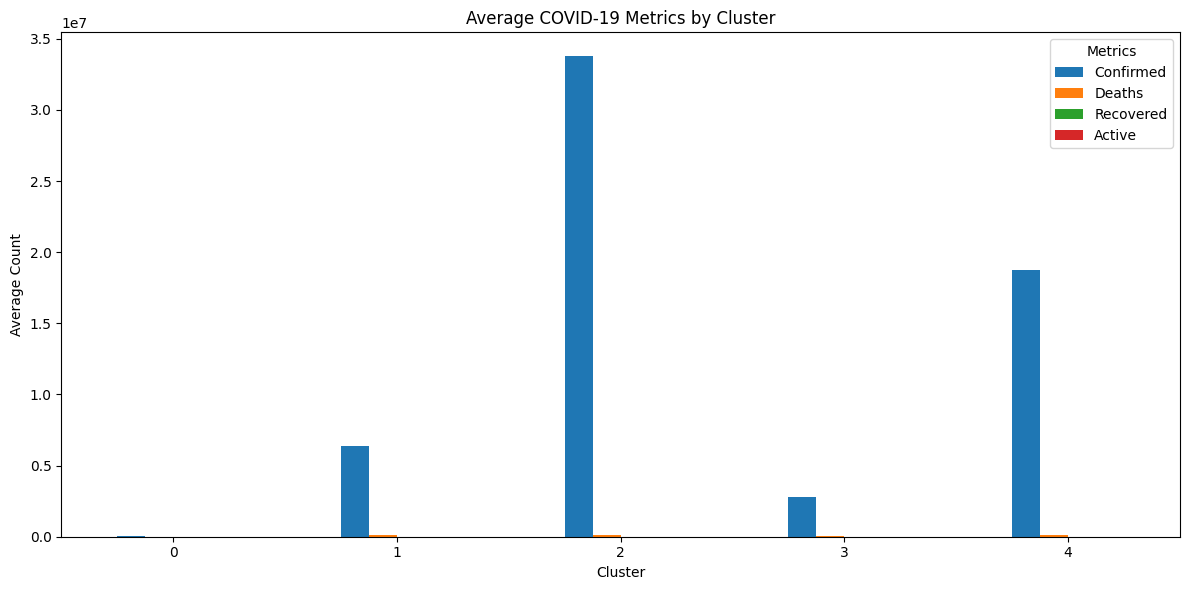


--- Key Insights ---

Cluster 0:
  - Number of regions: 3831
  - Avg Confirmed: 70837
  - Avg Deaths: 763
  - Severity Level: Low

Cluster 1:
  - Number of regions: 8
  - Avg Confirmed: 6401312
  - Avg Deaths: 134833
  - Severity Level: High

Cluster 2:
  - Number of regions: 2
  - Avg Confirmed: 33763338
  - Avg Deaths: 95469
  - Severity Level: High

Cluster 3:
  - Number of regions: 82
  - Avg Confirmed: 2813963
  - Avg Deaths: 26375
  - Severity Level: High

Cluster 4:
  - Number of regions: 2
  - Avg Confirmed: 18717530
  - Avg Deaths: 142420
  - Severity Level: High


In [8]:
# Cell 5: Evaluation & Data-Driven Decision Making

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Evaluate clustering performance
silhouette_avg = silhouette_score(df_scaled, df['Cluster'])
davies_bouldin = davies_bouldin_score(df_scaled, df['Cluster'])

print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

# Analyze clusters by severity
cluster_summary = df.groupby('Cluster')[['Confirmed', 'Deaths', 'Recovered', 'Active']].mean()
print("\nAverage metrics per cluster:")
print(cluster_summary)

# Visualize cluster characteristics
fig, ax = plt.subplots(figsize=(12, 6))
cluster_summary.plot(kind='bar', ax=ax)
plt.title('Average COVID-19 Metrics by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

# Key insights
print("\n--- Key Insights ---")
for cluster_id in range(optimal_clusters):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  - Number of regions: {len(cluster_data)}")
    print(f"  - Avg Confirmed: {cluster_data['Confirmed'].mean():.0f}")
    print(f"  - Avg Deaths: {cluster_data['Deaths'].mean():.0f}")
    print(f"  - Severity Level: {'High' if cluster_data['Confirmed'].mean() > df['Confirmed'].mean() else 'Low'}")